### Hyperparameter Tuning using Random Search for NAMs

In [51]:
import json
import random
import numpy as np
import os
from pathlib import Path
import subprocess
import time


In [ ]:
hp_search_space = {
    'dropout': [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'l2_regularization': (1e-6, 1e-4),
    'learning_rate': (0.001, 0.1),
    'feature_dropout': [0, 0.05, 0.1, 0.2],
    'output_regularization': (0.001, 0.1)
}

fixed_hp = {
    'training_epochs': 300,
    'dataset_name': 'Correlated_linear',

    # Parameters for correlated synthetic datasets
    'correlated_n': 1000,
    'correlated_rho': 0.8,
    'correlated_seed': 0,

    'num_basis_functions': 128,
    'activation': 'relu',
    'shallow': False,
    'regression': True,
    'debug': True,
    'use_dnn': False,
    'max_checkpoints_to_keep': 1,
    'save_checkpoint_every_n_epochs': 10,
    'n_models': 1,
    'num_splits': 3,
    'fold_num': 1,
    'data_split': 1,
    'tf_seed': 1,
    'batch_size': 1024,
    'units_multiplier': 2,
    'decay_rate': 0.995,
    'early_stopping_epochs': 300,
    'cross_val': False,
    'hyperparameter_tuning': True,
    'test_size': 0.2,
    'val_size': 0.2,
    'hp_random_state': 42
}



In [53]:
# Random search parameters
n_trials = 50
random_seed = 42
base_logdir = './hp_tuning_correlated_linear'



os.makedirs(base_logdir, exist_ok=True)

In [54]:
def sample_hyperparameters(hp_search_space, random_seed):
    """Sample hyperparameters from the search space.
    
    Handles both discrete sets (lists) and continuous intervals (tuples).
    """
    random.seed(random_seed)
    np.random.seed(random_seed)

    hp_config = {}
    for key, values in hp_search_space.items():
        if isinstance(values, tuple):
            # Continuous interval: sample uniformly from [min, max)
            min_val, max_val = values
            hp_config[key] = random.uniform(min_val, max_val)
        else:
            # Discrete set: choose randomly
            hp_config[key] = random.choice(values)
    return hp_config


def generate_training_command(hyperparameters, trial_num, data_split, base_logdir):
    """Generate a training command string from hyperparameters."""
    logdir = os.path.join(base_logdir, f'trial_{trial_num}')

    all_hp = {**fixed_hp, **hyperparameters}
    all_hp['logdir'] = logdir

    cmd = ['python', '-m', 'neural_additive_models.nam_train']

    for key, value in all_hp.items():
        if key == 'data_split':
            value = data_split

        if value is None:
            arg = f'--{key}=None'
        elif isinstance(value, bool):
            arg = f'--{key}={"true" if value else "false"}'
        else:
            arg = f'--{key}={value}'

        cmd.append(arg)

    return ' '.join(cmd), logdir


In [55]:
from utils import load_nam_checkpoint, get_test_predictions
import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder

def extract_validation_score(logdir, split_num=1):
    """Extract validation score by loading the trained model and evaluating on validation set.
    
    Args:
        logdir: Base log directory for the trial
        split_num: Split number (1-indexed). Defaults to 1.
    """

    # Load dataset and recreate the split
    data_x, data_y, _ = data_utils.load_dataset(
        fixed_hp['dataset_name'],
        correlated_n=fixed_hp.get('correlated_n'),
        correlated_rho=fixed_hp.get('correlated_rho'),
        correlated_seed=fixed_hp.get('correlated_seed'),
    )
    (x_train, y_train), (x_val, y_val), (x_test, y_test) = \
        data_utils.get_train_val_test_split(
            data_x, data_y,
            test_size=fixed_hp['test_size'],
            val_size=fixed_hp['val_size'],
            stratified=not fixed_hp['regression'],
            random_state=fixed_hp['hp_random_state']
        )
    
    # In hyperparameter tuning mode, the logdir structure is: logdir/fold_1/split_{split_num}/model_0/best_checkpoint
    checkpoint_dir = os.path.join(logdir, 'fold_1', f'split_{split_num}', 'model_0', 'best_checkpoint')
    
    if not os.path.exists(checkpoint_dir):
        print(f"Checkpoint directory not found: {checkpoint_dir}")
        return None
    
    # Load model and get predictions
    nam, sess = load_nam_checkpoint(checkpoint_dir)
    preds = get_test_predictions(nam, x_val.astype(np.float32), sess)
    
    # Calculate metric
    score = graph_builder.calculate_metric(
        y_val, preds, regression=fixed_hp['regression']
    )
    
    sess.close()
    return float(score)


In [56]:
hyperparameters = []

for trial in range(n_trials):
    hp_config = sample_hyperparameters(hp_search_space, random_seed)
    trial_num = trial + 1
    
    hyperparameters.append({
        'trial': trial_num,
        'hyperparameters': hp_config.copy()
    })
    


In [57]:
import re

# Run settings
num_splits = fixed_hp['num_splits']          # 3
trials_to_run = range(1, n_trials + 1)       # 50 trials
skip_if_exists = True
per_split_timeout_s = 3600

for trial_num in trials_to_run:
    trial_data = hyperparameters[trial_num - 1]
    assert trial_data['trial'] == trial_num

    split_results_file = os.path.join(base_logdir, f'trial_{trial_num}_split_results.json')
    if skip_if_exists and os.path.exists(split_results_file):
        print(f"Skipping trial {trial_num}: {split_results_file} already exists")
        continue

    print(f"\n=== Trial {trial_num}/{n_trials} ===")
    split_results = []

    for split_idx in range(num_splits):
        print(f"Running split {split_idx+1}/{num_splits} for trial {trial_num}...")

        split_cmd, _ = generate_training_command(
            trial_data['hyperparameters'],
            trial_num,
            split_idx + 1,  # data_split is 1-indexed
            base_logdir,
        )

        start_time = time.time()
        result = subprocess.run(
            split_cmd,
            shell=True,
            capture_output=True,
            text=True,
            timeout=per_split_timeout_s,
        )
        training_time = time.time() - start_time
        success = result.returncode == 0

        print(f"  Completed in {training_time:.1f}s (success={success})")

        split_results.append({
            'split': split_idx,
            'command': split_cmd,
            'training_time': training_time,
            'success': success,
            'returncode': result.returncode,
            'stdout_tail': result.stdout[-4000:] if result.stdout else '',
            'stderr_tail': result.stderr[-4000:] if result.stderr else '',
        })

    with open(split_results_file, 'w') as f:
        json.dump({
            'trial': trial_num,
            'hyperparameters': trial_data['hyperparameters'],
            'split_results': split_results,
        }, f, indent=2)

    print(f"Saved: {split_results_file}")



=== Trial 1/50 ===
Running split 1/3 for trial 1...
  Completed in 32.9s (success=True)
Running split 2/3 for trial 1...
  Completed in 36.0s (success=True)
Running split 3/3 for trial 1...
  Completed in 37.6s (success=True)
Saved: ./hp_tuning_correlated_linear\trial_1_split_results.json

=== Trial 2/50 ===
Running split 1/3 for trial 2...
  Completed in 42.5s (success=True)
Running split 2/3 for trial 2...
  Completed in 41.7s (success=True)
Running split 3/3 for trial 2...
  Completed in 44.0s (success=True)
Saved: ./hp_tuning_correlated_linear\trial_2_split_results.json

=== Trial 3/50 ===
Running split 1/3 for trial 3...
  Completed in 48.1s (success=True)
Running split 2/3 for trial 3...
  Completed in 46.5s (success=True)
Running split 3/3 for trial 3...
  Completed in 47.4s (success=True)
Saved: ./hp_tuning_correlated_linear\trial_3_split_results.json

=== Trial 4/50 ===
Running split 1/3 for trial 4...
  Completed in 50.2s (success=True)
Running split 2/3 for trial 4...
  Com

In [58]:
import tensorflow as tf
import re
import numpy as np
from neural_additive_models.models import NAM

tf.compat.v1.disable_eager_execution()

def load_nam_checkpoint(ckpt_dir: str, hyperparameters=None):
    """Load a NAM from a TensorFlow v1 checkpoint directory."""
    # --- Locate checkpoint ---
    ckpt_path = tf.compat.v1.train.latest_checkpoint(ckpt_dir)
    if ckpt_path is None:
        ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith('.index')]
        if not ckpt_files:
            raise FileNotFoundError(f"No valid checkpoint found in {ckpt_dir}")
        name = ckpt_files[0].split('.index')[0]
        ckpt_path = os.path.join(ckpt_dir, name)
    print(f"Using checkpoint: {ckpt_path}")

    # --- Read variable shapes to reconstruct model architecture ---
    reader = tf.compat.v1.train.NewCheckpointReader(ckpt_path)
    var_map = reader.get_variable_to_shape_map()

    units_by_idx = {}
    for name, shape in var_map.items():
        m = re.match(r"^model_0/activation_layer_(\d+)/beta$", name)
        if m:
            units_by_idx[int(m.group(1))] = shape[1]

    if not units_by_idx:
        raise ValueError("Could not infer unit shapes from checkpoint metadata.")

    num_units_list = [units_by_idx[i] for i in sorted(units_by_idx)]
    num_inputs = len(num_units_list)

    # --- Build the model with hyperparameters ---
    tf.compat.v1.reset_default_graph()
    hp = hyperparameters or {}
    nam = NAM(
        num_inputs=num_inputs,
        num_units=num_units_list,
        dropout=float(hp.get('dropout', 0.0)),
        feature_dropout=float(hp.get('feature_dropout', 0.0)),
        activation=hp.get('activation', 'relu'),
        shallow=hp.get('shallow', False),
        trainable=False,
        name_scope='model_0'
    )
    _ = nam(np.zeros((1, num_inputs), np.float32), training=False)

    # --- Restore weights ---
    sess = tf.compat.v1.Session()
    saver = tf.compat.v1.train.Saver()
    saver.restore(sess, ckpt_path)
    return nam, sess

In [59]:

def extract_validation_score_for_split(logdir, split_num, hyperparameters=None):
    """Extract validation score for a specific split.
    
    Args:
        logdir: Base logdir for the trial (e.g., './hp_tuning/trial_1')
        split_num: Split number (1-indexed)
        hyperparameters: Not used (kept for compatibility)
    
    Returns:
        Validation score (RMSE for regression, AUROC for classification) or None if failed
    """
    try:
        from utils import get_test_predictions
        import neural_additive_models.data_utils as data_utils
        import neural_additive_models.graph_builder as graph_builder
        
        # Load dataset and recreate the split (must match the training split)
        data_x, data_y, _ = data_utils.load_dataset(
            fixed_hp['dataset_name'],
            correlated_n=fixed_hp.get('correlated_n'),
            correlated_rho=fixed_hp.get('correlated_rho'),
            correlated_seed=fixed_hp.get('correlated_seed'),
        )
        (x_train, y_train), (x_val, y_val), (x_test, y_test) = \
            data_utils.get_train_val_test_split(
                data_x, data_y,
                test_size=fixed_hp['test_size'],
                val_size=fixed_hp['val_size'],
                stratified=not fixed_hp['regression'],
                random_state=fixed_hp['hp_random_state']
            )
        
        # In hyperparameter tuning mode, the logdir structure is: logdir/fold_1/split_{split_num}/model_0/best_checkpoint
        checkpoint_dir = os.path.join(logdir, 'fold_1', f'split_{split_num}', 'model_0', 'best_checkpoint')
        
        if not os.path.exists(checkpoint_dir):
            return None

        # Reconstruct the exact same model architecture that was trained.
        hp = dict(hyperparameters or {})
        hp['activation'] = fixed_hp['activation']
        hp['shallow'] = fixed_hp['shallow']

        nam, sess = load_nam_checkpoint(checkpoint_dir, hyperparameters=hp)
        
        # Get validation predictions (similar to how NAMs_housing gets test predictions)
        preds_val = get_test_predictions(nam, x_val.astype(np.float32), sess)
        
        # Calculate metric
        score = graph_builder.calculate_metric(
            y_val, preds_val, regression=fixed_hp['regression']
        )
        
        sess.close()
        return float(score)
    except Exception as e:
        print(f"Error extracting validation score from {logdir}, split {split_num}: {e}")
        return None


split_results_files = list(Path(base_logdir).glob('trial_*_split_results.json'))

In [60]:
import pandas as pd

results = []
for split_file in split_results_files:
    with open(split_file, 'r') as f:
        data = json.load(f)
    logdir = os.path.join(base_logdir, f'trial_{data["trial"]}')
    for split_result in data['split_results']:
        if split_result.get('success'):
            validation_score = extract_validation_score_for_split(
                logdir, split_result['split'] + 1, 
                hyperparameters=data.get('hyperparameters')
            )
            if validation_score is not None:
                results.append({
                    'trial': data['trial'],
                    'split': split_result['split'],
                    'validation_score': validation_score
                })

df = pd.DataFrame(results)


Using checkpoint: ./hp_tuning_correlated_linear\trial_10\fold_1\split_1\model_0\best_checkpoint\model.ckpt-10
INFO:tensorflow:Restoring parameters from ./hp_tuning_correlated_linear\trial_10\fold_1\split_1\model_0\best_checkpoint\model.ckpt-10
Using checkpoint: ./hp_tuning_correlated_linear\trial_10\fold_1\split_2\model_0\best_checkpoint\model.ckpt-20
INFO:tensorflow:Restoring parameters from ./hp_tuning_correlated_linear\trial_10\fold_1\split_2\model_0\best_checkpoint\model.ckpt-20
Using checkpoint: ./hp_tuning_correlated_linear\trial_10\fold_1\split_3\model_0\best_checkpoint\model.ckpt-20
INFO:tensorflow:Restoring parameters from ./hp_tuning_correlated_linear\trial_10\fold_1\split_3\model_0\best_checkpoint\model.ckpt-20
Using checkpoint: ./hp_tuning_correlated_linear\trial_11\fold_1\split_1\model_0\best_checkpoint\model.ckpt-40
INFO:tensorflow:Restoring parameters from ./hp_tuning_correlated_linear\trial_11\fold_1\split_1\model_0\best_checkpoint\model.ckpt-40
Using checkpoint: ./hp_t

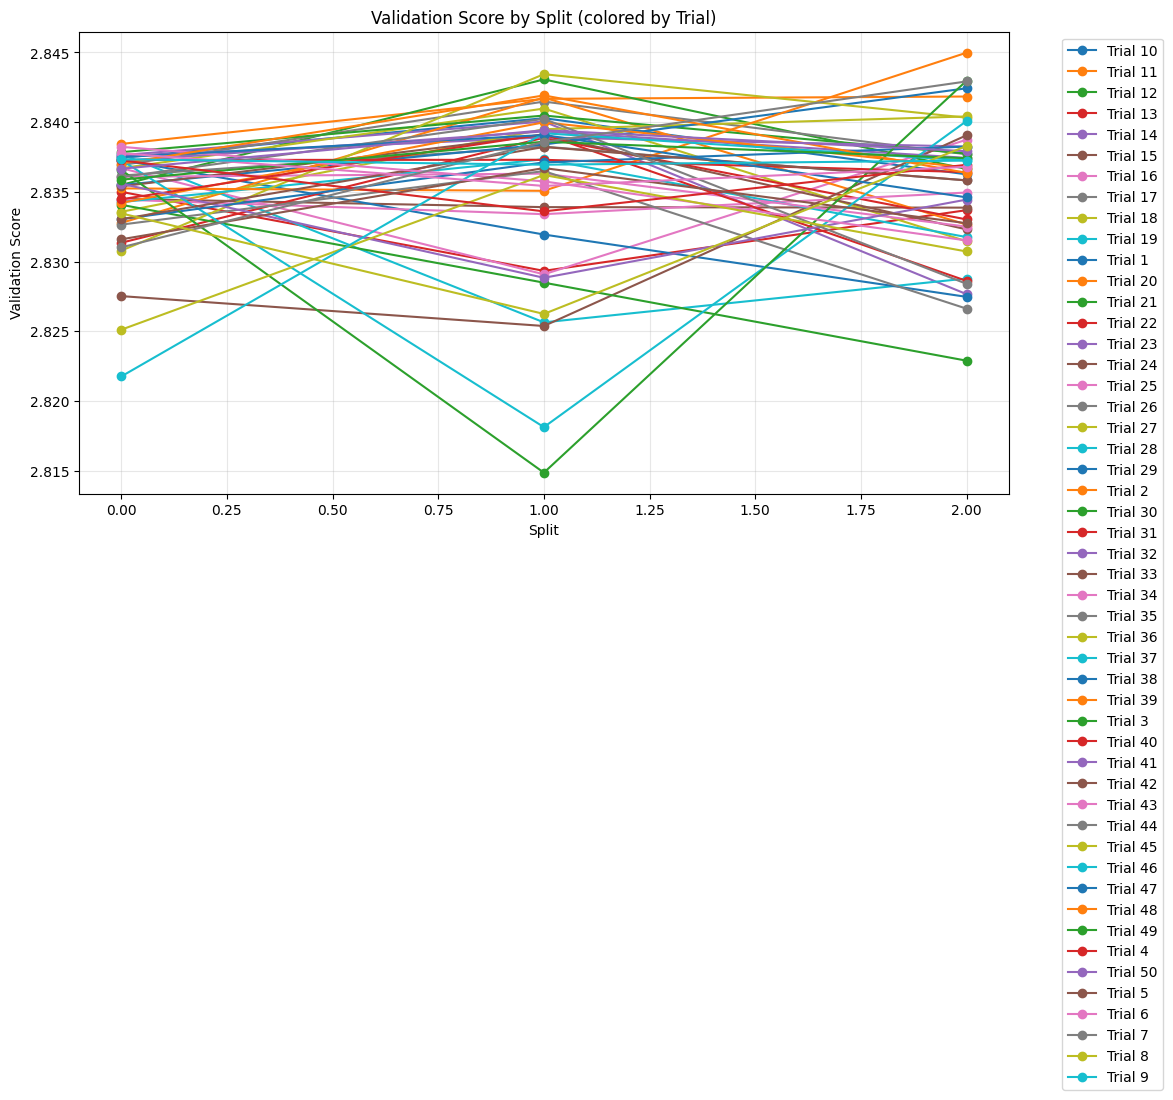

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for trial in df['trial'].unique():
    trial_data = df[df['trial'] == trial]
    plt.plot(trial_data['split'], trial_data['validation_score'], marker='o', label=f'Trial {trial}')
plt.xlabel('Split')
plt.ylabel('Validation Score')
plt.title('Validation Score by Split (colored by Trial)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [64]:
best_trial = df.groupby('trial')['validation_score'].mean().idxmin()
with open(os.path.join(base_logdir, f'trial_{best_trial}_split_results.json'), 'r') as f:
    best_data = json.load(f)

print(f"Best trial: {best_trial} (avg validation score: {df.groupby('trial')['validation_score'].mean().min():.4f})")
print(f"\nHyperparameters:")
for key, value in best_data['hyperparameters'].items():
    print(f"  {key}: {value}")

# Save best hyperparameters as JSON
best_hp_path = os.path.join(base_logdir, f"best_hp.json")
with open(best_hp_path, "w") as fout:
    json.dump(best_data["hyperparameters"], fout, indent=2)
print(f"\nBest hyperparameters saved to: {best_hp_path}")


Best trial: 30 (avg validation score: 2.8285)

Hyperparameters:
  dropout: 0.9
  l2_regularization: 1.202177574840236e-05
  learning_rate: 0.07441349947622346
  feature_dropout: 0.05
  output_regularization: 0.023097863076733453

Best hyperparameters saved to: ./hp_tuning_correlated_linear\best_hp.json
